# Data Preprocessing

In [141]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [142]:
df=pd.read_csv("ridge_regression.csv")

In [143]:
df

,feature_1,feature_2_mc,feature_3_mc,feature_4,feature_5,feature_6_mc,feature_7,feature_8,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,target
0,67.548412,136.681113,74.904058,11.160537,394.588486,13.926652,-16.522447,0.421922,0.690173,0.130746,-0.231793,-0.007802,0.457751,1.374572,-0.677779,-0.196643,-1.541875,-0.968554,134.043083
1,10.584888,22.233329,10.508898,17.012526,162.191800,28.139002,-16.290166,0.096716,0.782327,-1.113222,0.568251,-1.514520,-2.619945,-0.606891,-0.915810,0.876012,0.664266,-1.219075,-26.813823
2,87.553621,172.345672,94.751066,2.291219,191.159310,3.137131,-10.688365,0.101001,-0.248490,1.399186,-0.635147,0.721966,0.198365,0.762765,1.332185,-0.560118,-0.474221,-0.387968,251.913937
3,75.621412,152.254209,84.322786,49.476168,355.999904,69.945374,13.714077,0.776000,0.033531,0.253237,-0.315592,0.723632,0.580780,2.321409,0.619968,-0.609403,-0.561798,-0.831581,169.374137
4,92.309283,183.101710,101.285729,12.331375,324.547254,18.179052,15.912915,0.399401,0.663990,3.401817,-0.435820,-0.026117,0.460988,0.140603,-1.233827,-1.272347,-0.319837,0.170221,317.867018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,85.933904,168.397963,92.631558,41.669726,278.117956,59.950702,-14.087722,0.861443,1.180555,-0.605156,0.319686,1.735689,1.590589,1.001449,-0.457559,1.093339,0.009035,-1.676065,158.463890
996,51.821150,103.620843,55.285440,33.446798,178.063548,49.890993,9.776528,0.121861,0.073816,1.323277,2.517548,0.165304,-1.916619,-0.398649,0.853120,-0.081948,-0.527589,-0.691923,120.703157
997,20.913632,41.729878,22.685966,2.953540,312.447516,6.905279,14.223410,0.717179,0.859284,0.236330,0.612395,-0.580024,-0.149932,-0.663578,0.830521,0.388768,-0.573233,-1.662678,73.334903
998,54.657041,107.843249,60.379837,45.750630,131.546358,67.311814,3.983354,0.568350,0.189715,0.719818,-1.146777,-1.059161,-0.877698,-0.895878,2.707420,-0.421357,0.577034,-0.889931,80.558724


In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   feature_1     1000 non-null   float64
 1   feature_2_mc  1000 non-null   float64
 2   feature_3_mc  1000 non-null   float64
 3   feature_4     1000 non-null   float64
 4   feature_5     1000 non-null   float64
 5   feature_6_mc  1000 non-null   float64
 6   feature_7     1000 non-null   float64
 7   feature_8     1000 non-null   float64
 8   noise_1       1000 non-null   float64
 9   noise_2       1000 non-null   float64
 10  noise_3       1000 non-null   float64
 11  noise_4       1000 non-null   float64
 12  noise_5       1000 non-null   float64
 13  noise_6       1000 non-null   float64
 14  noise_7       1000 non-null   float64
 15  noise_8       1000 non-null   float64
 16  noise_9       1000 non-null   float64
 17  noise_10      1000 non-null   float64
 18  target        1000 non-null   float64
dt

In [145]:
df.describe()

,feature_1,feature_2_mc,feature_3_mc,feature_4,feature_5,feature_6_mc,feature_7,feature_8,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,55.877428,111.724878,61.396318,24.762379,301.629395,37.200431,0.269567,0.501323,-0.001843,0.011812,-0.006768,-0.030593,0.021752,-0.022160,-0.003164,0.011103,-0.022986,0.033537,134.731532
std,26.045613,52.176803,28.742125,14.295666,117.553525,21.670784,11.541938,0.289343,0.986241,1.016608,0.980147,0.993824,0.986796,0.954517,1.001982,0.981457,1.018548,0.998341,87.646021
min,10.131584,17.925736,8.879100,0.009217,101.146442,-6.054849,-19.948754,0.001678,-3.043403,-3.000637,-3.331354,-3.330694,-2.973270,-2.822217,-2.980414,-3.351725,-3.120927,-3.534826,-84.916853
25%,34.205840,67.500233,37.437138,12.892174,197.181321,19.294973,-10.063501,0.247844,-0.691681,-0.689028,-0.623580,-0.708279,-0.664205,-0.725717,-0.698298,-0.592200,-0.687885,-0.656159,63.292901
50%,57.631922,115.362989,63.253541,24.296902,305.411795,36.580163,0.473340,0.503187,-0.005111,-0.007839,-0.041163,-0.021693,0.056659,-0.018325,0.010650,0.023062,-0.004786,0.028390,137.443170
75%,77.874406,155.101923,85.637374,36.646095,402.537419,55.806480,10.250930,0.752140,0.640627,0.692760,0.611312,0.644062,0.701034,0.665070,0.600816,0.634316,0.664472,0.734914,205.959078
max,99.885536,201.818048,110.722534,49.978621,499.417917,81.048529,19.996313,0.999282,3.588850,3.646272,2.931068,3.288771,3.449000,3.169629,3.089478,3.062199,2.845481,3.098311,338.687978


In [146]:
df.shape

(1000, 19)

In [147]:
df.dtypes

feature_1       float64
feature_2_mc    float64
feature_3_mc    float64
feature_4       float64
feature_5       float64
feature_6_mc    float64
feature_7       float64
feature_8       float64
noise_1         float64
noise_2         float64
noise_3         float64
noise_4         float64
noise_5         float64
noise_6         float64
noise_7         float64
noise_8         float64
noise_9         float64
noise_10        float64
target          float64
dtype: object

# EDA

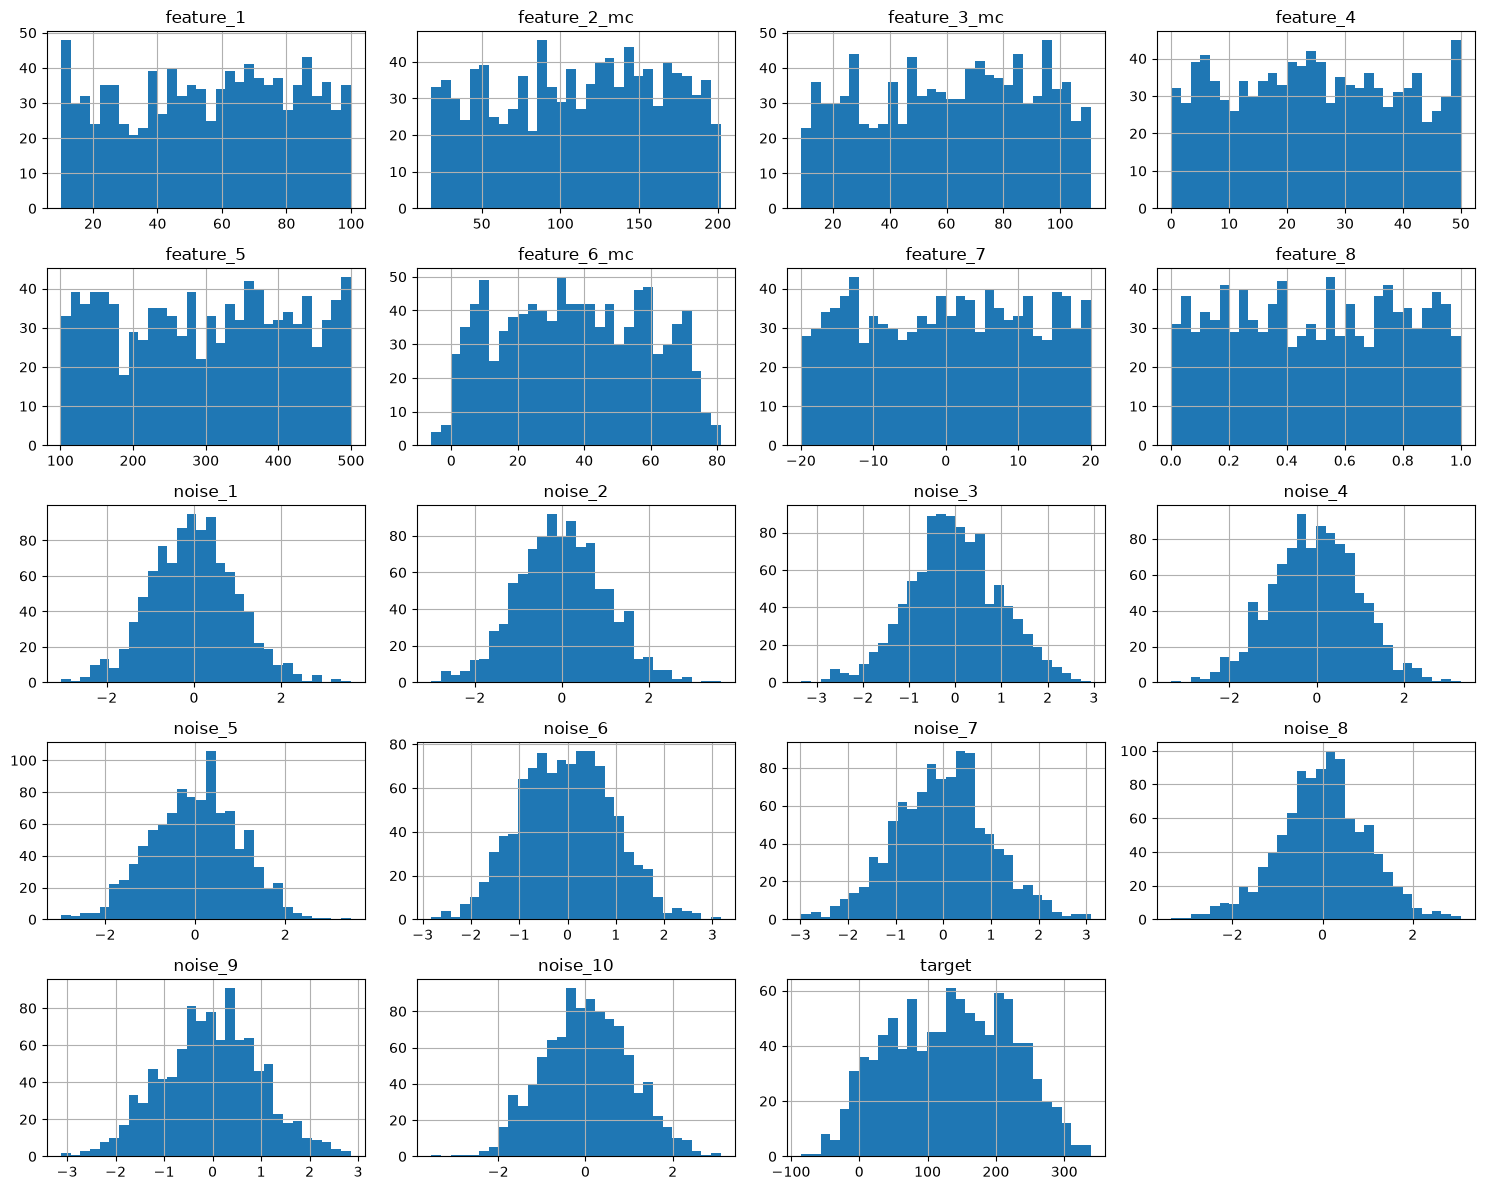

In [170]:
df.hist(figsize=(15,12),bins=30)
plt.tight_layout()
plt.show()

# Model Training

### LINEAR REGRESSION

In [148]:
X=df.drop("target",axis=1)
y=df["target"]

In [149]:
X.shape

(1000, 18)

In [150]:
y.shape

(1000,)

In [151]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [152]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [153]:
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

In [154]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,mean_squared_error

MSE=mean_squared_error(y_test,y_pred)

MAE=mean_absolute_error(y_test,y_pred)

R2=r2_score(y_test,y_pred)

print("MSE:      ",MSE)
print("MAE:      ",MAE)
print("R2_score: ",R2)

MSE:       260.6851823053077
MAE:       12.996323934200932
R2_score:  0.9674605691991364


### POLYNOMIAL REGRESSION

In [155]:
# XX=df[['feature_1', 'feature_2_mc', 'feature_3_mc', 'feature_4', 'feature_5',
#        'feature_6_mc', 'feature_7', 'feature_8', 'noise_1', 'noise_2',
#        'noise_3', 'noise_4', 'noise_5', 'noise_6', 'noise_7', 'noise_8',
#        'noise_9', 'noise_10',]]

# yy=df["target"]

In [156]:
X.shape

(1000, 18)

In [157]:
y.shape

(1000,)

In [158]:
from sklearn.preprocessing import PolynomialFeatures,StandardScaler

poly=PolynomialFeatures(degree=2)

x_train_poly=poly.fit_transform(X_train)
x_test_poly=poly.transform(X_test)


In [159]:
# scale polynomial features
scaler=StandardScaler()

x_train_scaled=poly.fit_transform(x_train_poly)
x_test_scaled=poly.transform(x_test_poly)


model=LinearRegression()

In [160]:
from sklearn.linear_model import LinearRegression



model=model.fit(x_train_scaled,y_train)

y_pred=model.predict(x_test_scaled)

In [161]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error,r2_score

MSEE=mean_squared_error(y_test,y_pred)

MAEE=mean_absolute_error(y_test,y_pred)

R22=r2_score(y_test,y_pred)


print("MSE:      ",MSEE)
print("MAE:      ",MAEE)
print("R2_score: ",R22)

MSE:       763.9741292279846
MAE:       21.212315899727614
R2_score:  0.9046386791461377


### RIDGE REGRESSION

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [163]:
# ?feature scaling

scalar=StandardScaler()

X_train_scaled=scalar.fit_transform(X_train)
X_test_scaled=scalar.transform(X_test)

In [164]:
# creating the ridge model

ridge=Ridge(alpha=1.0)


# training model

ridge.fit(X_train_scaled,y_train)


,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [165]:
# prediction

y_pred=ridge.predict(X_test_scaled)

In [166]:
# Evaluation

mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_pred,y_test)
r=r2_score(y_pred,y_test)

print("MSE:      ",mse)
print("MAE:      ",mae)
print("R2_score: ",r)

MSE:       257.0699093936609
MAE:       12.968028503183184
R2_score:  0.9667340133757726


### LASSO REGRESSION

In [167]:
from sklearn.linear_model import Lasso

# lasso model creation
lasso=Lasso(alpha=0.1,max_iter=10000)

# train model
lasso.fit(X_train,y_train)




,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [168]:
# prediction

y_pred=lasso.predict(X_test_scaled)

c:\Users\vaish\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [169]:
# Evaluation
Mse=mean_squared_error(y_pred,y_test)
Mae=mean_absolute_error(y_pred,y_test)
r2=r2_score(y_test,y_pred)

print("MSE:      ",Mse)
print("MAE:      ",Mae)
print("R2_score: ",r2)

MSE:       26086.68674058439
MAE:       139.72121559599745
R2_score:  -2.2562109227401552
